In [1]:
import sys
import warnings
import yaml
from pathlib import Path
# Add parent directory to path to import from src/
sys.path.append(str(Path(__file__).parent.parent) if '__file__' in globals() else str(Path.cwd().parent))
from sionna.rt import (load_scene, Receiver)
from src.base_station import set_tx_antenna_array, add_base_station
from src.user_equipment import set_rx_antenna_array
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import subprocess
import tempfile
from pathlib import PurePath

jitc_llvm_init(): LLVM API initialization failed ..


In [2]:
def normalize_channels(
    channels: np.ndarray,
    *,
    per_sample: bool = False,
    eps: float = 1e-30,
) -> np.ndarray:
    """
    Normalize complex channels by power normalization.

    Divides each channel coefficient by sqrt(mean power), so that
    the normalized channel has unit mean power: E[|H_norm|^2] = 1.

    Args:
        channels:   Complex array of any shape, where axis 0 is the sample axis.
        per_sample: If True, normalize each sample by its own power (removes path loss,
                    isolates small-scale fading structure).
                    If False, normalize by global mean power across the entire array.
        eps:        Small constant to avoid division by zero.

    Returns:
        Power-normalized complex array of same shape, dtype complex64.
    """
    h = np.asarray(channels)

    if not np.iscomplexobj(h):
        raise ValueError(f"`channels` must be complex; got dtype={h.dtype}")

    if per_sample:
        sample_axes = tuple(range(1, h.ndim))
        mean_power = np.mean(np.abs(h) ** 2, axis=sample_axes, keepdims=True)

        clipped = mean_power < eps
        if np.any(clipped):
            n_clipped = int(np.sum(clipped))
            warnings.warn(
                f"{n_clipped} sample(s) have mean_power < eps={eps:.3e}; "
                "eps will be used as the denominator for those samples. "
                "Check for zero or near-zero channels.",
                RuntimeWarning,
                stacklevel=2,
            )
    else:
        mean_power = np.mean(np.abs(h) ** 2)

        if mean_power < eps:
            warnings.warn(
                f"Global mean_power={mean_power:.3e} < eps={eps:.3e}; "
                "eps will be used as the denominator. "
                "Check for zero or near-zero channels.",
                RuntimeWarning,
                stacklevel=2,
            )

    mean_power = np.maximum(mean_power, eps)
    h_norm = h / np.sqrt(mean_power)

    return h_norm.astype(np.complex64, copy=False)

In [3]:
# Resolve repo root whether the notebook cwd is repo/ or examples/
_cwd = Path.cwd().resolve()
if (_cwd / "scripts" / "run.py").exists():
    REPO_ROOT = _cwd
elif (_cwd.parent / "scripts" / "run.py").exists():
    REPO_ROOT = _cwd.parent
else:
    raise RuntimeError(
        "Cannot find scripts/run.py. "
        "Set the working directory to CSIGen repo root or CSIGen/examples."
    )

BASELINE_LA = yaml.safe_load(
    (REPO_ROOT / "config/pilotwimae_dataset_configs/eval/la_config_test.yaml").read_text()
)

CUSTOM_CONFIG = copy.deepcopy(BASELINE_LA)
# LA scene, compact run: 2 BS, 3 sectors, horizontal 8-element ULA, 20 users sampled per TX
CUSTOM_CONFIG["num_deployment_buildings"] = 2
CUSTOM_CONFIG["num_sectors"] = 3
CUSTOM_CONFIG["tx_num_rows"] = 1
CUSTOM_CONFIG["tx_num_cols"] = 8
CUSTOM_CONFIG["num_user_samples_per_tx"] = 20

fd, cfg_path_str = tempfile.mkstemp(prefix="notebook_los_", suffix=".yaml", dir=str(REPO_ROOT / "examples"))
os.close(fd)

cfg_path = Path(cfg_path_str)
with open(cfg_path, "w") as f_out:
    yaml.dump(CUSTOM_CONFIG, f_out, sort_keys=False, allow_unicode=True)

print(f"Wrote notebook config: {cfg_path}")
subprocess.run(
    [sys.executable, str(REPO_ROOT / "scripts/run.py"), "--config", str(cfg_path)],
    cwd=str(REPO_ROOT),
    check=True,
)

Wrote notebook config: /home/berkay/Desktop/research/2026/CSIGen/examples/notebook_los_q6x6_ucg.yaml


jitc_llvm_init(): LLVM API initialization failed ..
2026-05-17 13:21:27,936 - __main__ - INFO - Loading and validating configuration from /home/berkay/Desktop/research/2026/CSIGen/examples/notebook_los_q6x6_ucg.yaml
2026-05-17 13:21:27,936 - src.config_validator - INFO - Loading configuration from /home/berkay/Desktop/research/2026/CSIGen/examples/notebook_los_q6x6_ucg.yaml
2026-05-17 13:21:27,939 - src.config_validator - INFO - Configuration validation successful!
2026-05-17 13:21:27,939 - __main__ - INFO - Starting channel generation (streaming per TX)...
2026-05-17 13:21:27,939 - src.channel_generator - INFO - Step 1: Setting up scene...
2026-05-17 13:21:28,086 - src.scene_setup - INFO - Overrode ground material to itu_concrete
2026-05-17 13:21:28,092 - src.scene_setup - INFO - Building bounds: x=[-491.7, 488.2], y=[-463.5, 515.8]
2026-05-17 13:21:28,095 - src.utils - INFO - Clipped terrain: clamped 51253/194617 vertices to bounds
2026-05-17 13:21:28,095 - src.utils - INFO -   Bound

2026-05-17 13:21:27 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


2026-05-17 13:21:29,355 - src.channel_generator - INFO - Step 5: Sampling user positions...
2026-05-17 13:21:29,393 - src.channel_generator - INFO - Step 5.5: Filtering positions by edge distance...
2026-05-17 13:21:29,393 - src.radio_map - INFO - Measurement surface bounds: x=[-501.2, 488.5], y=[-478.5, 520.4]
2026-05-17 13:21:29,394 - src.radio_map - INFO - Filtering users within 1.0 m of measurement surface edges...
2026-05-17 13:21:29,394 - src.radio_map - INFO -   TX 0: kept 19/20 users (removed 1)
2026-05-17 13:21:29,394 - src.radio_map - INFO -   TX 1: kept 19/20 users (removed 1)
2026-05-17 13:21:29,394 - src.radio_map - INFO -   TX 2: kept 20/20 users (removed 0)
2026-05-17 13:21:29,394 - src.radio_map - INFO -   TX 3: kept 20/20 users (removed 0)
2026-05-17 13:21:29,394 - src.radio_map - INFO -   TX 4: kept 19/20 users (removed 1)
2026-05-17 13:21:29,394 - src.radio_map - INFO -   TX 5: kept 19/20 users (removed 1)
2026-05-17 13:21:29,394 - src.radio_map - INFO - Filtering co

Saved channel data to output/la_1/20260517_132127/channel_tx_0.npz
  Shape: (110, 1, 1, 8, 14, 32)
  Dtype: complex64
  Metadata keys: ['tx_idx', 'tx_name', 'tx_position', 'rx_positions', 'rx_names', 'los_binary', 'num_txs', 'num_users_per_tx', 'total_users', 'num_sectors', 'num_valid_channels', 'cfr_shape', 'cfr_dtype', 'config']


...

2026-05-17 13:22:07,896 - src.channel - INFO - Single TX CFR shape (114, 1, 1, 8, 14, 32)
2026-05-17 13:22:07,898 - src.channel_generator - INFO - TX 4: filtering out 2 users with no valid paths (keeping 112 of 114; LoS=50, NLoS=62)
2026-05-17 13:22:08,011 - __main__ - INFO - Saved channel data for TX 4 (BS_1_sector_2) to output/la_1/20260517_132127/channel_tx_4.npz (112 valid channels)
2026-05-17 13:22:08,011 - src.path_solver - INFO - TX 5 (BS_1_sector_3): Solving paths for all 114 users
2026-05-17 13:22:08,011 - src.path_solver - INFO - Solving paths for TX 5 (BS_1_sector_3) with 114 receivers
2026-05-17 13:22:08,011 - src.path_solver - INFO - Scene receivers: 114
2026-05-17 13:22:08,011 - src.path_solver - INFO - Scene transmitters: 1


Saved channel data to output/la_1/20260517_132127/channel_tx_4.npz
  Shape: (112, 1, 1, 8, 14, 32)
  Dtype: complex64
  Metadata keys: ['tx_idx', 'tx_name', 'tx_position', 'rx_positions', 'rx_names', 'los_binary', 'num_txs', 'num_users_per_tx', 'total_users', 'num_sectors', 'num_valid_channels', 'cfr_shape', 'cfr_dtype', 'config']


2026-05-17 13:22:15,153 - src.channel - INFO - Single TX CFR shape (114, 1, 1, 8, 14, 32)
2026-05-17 13:22:15,155 - src.channel_generator - INFO - TX 5: filtering out 2 users with no valid paths (keeping 112 of 114; LoS=50, NLoS=62)
2026-05-17 13:22:15,268 - __main__ - INFO - Saved channel data for TX 5 (BS_1_sector_3) to output/la_1/20260517_132127/channel_tx_5.npz (112 valid channels)
2026-05-17 13:22:15,271 - __main__ - INFO - Saved metadata summary to output/la_1/20260517_132127/metadata.yaml
2026-05-17 13:22:15,271 - __main__ - INFO - Channel generation and saving complete!
2026-05-17 13:22:15,271 - __main__ - INFO - Output directory: output/la_1/20260517_132127


Saved channel data to output/la_1/20260517_132127/channel_tx_5.npz
  Shape: (112, 1, 1, 8, 14, 32)
  Dtype: complex64
  Metadata keys: ['tx_idx', 'tx_name', 'tx_position', 'rx_positions', 'rx_names', 'los_binary', 'num_txs', 'num_users_per_tx', 'total_users', 'num_sectors', 'num_valid_channels', 'cfr_shape', 'cfr_dtype', 'config']


CompletedProcess(args=['/home/berkay/miniconda3/envs/sionna/bin/python', '/home/berkay/Desktop/research/2026/CSIGen/scripts/run.py', '--config', '/home/berkay/Desktop/research/2026/CSIGen/examples/notebook_los_q6x6_ucg.yaml'], returncode=0)

In [4]:
# Folder nested under scenes/ (./scenes/la_1/scene.xml → la_1)
_city = PurePath(str(CUSTOM_CONFIG["scene_xml_path"]))
city = _city.parent.name

out_root = REPO_ROOT / "output" / city
run_dirs = sorted(p for p in out_root.glob("*") if p.is_dir())
if not run_dirs:
    raise RuntimeError(f"No output runs under {out_root}")
data_dir = run_dirs[-1]
print(f"Using latest generation folder: {data_dir}")

dataset_name = "notebook_generated"
npz_files = sorted(
    data_dir.glob("channel_tx_*.npz"),
    key=lambda p: int(p.stem.rsplit('_', maxsplit=1)[-1]),
)

NUM_SECTORS = int(CUSTOM_CONFIG["num_sectors"])

# select a BS and sector to analyze
# each (BS, sector) pair is saved in a separate .npz file
BS_IDX = 0
SECTOR_IDX = 0
file_idx = BS_IDX * NUM_SECTORS + SECTOR_IDX

npz_file = npz_files[file_idx]
scene_dir = REPO_ROOT / "scenes" / city
scene_xml_path = scene_dir / "scene.xml"
print(f"Loading {npz_file.name} (BS_IDX={BS_IDX}, SECTOR_IDX={SECTOR_IDX}, file_idx={file_idx})")


Using latest generation folder: /home/berkay/Desktop/research/2026/CSIGen/output/la_1/20260517_132127
Loading channel_tx_0.npz (BS_IDX=0, SECTOR_IDX=0, file_idx=0)


In [7]:
with np.load(npz_file, allow_pickle=True) as data:
    print("The shape of the data is ", data["h"].shape)

    # Read metadata and antenna geometry
    meta = data["metadata"].item()
    cfg = meta["config"]

    # Antenna array geometry (must be present in metadata)
    if "tx_num_rows" not in cfg or "tx_num_cols" not in cfg:
        raise RuntimeError(
            "Antenna geometry not found in metadata config "
            "(expected 'tx_num_rows' and 'tx_num_cols')."
        )

    # Subcarrier spacing from config is stored in Hz
    if "subcarrier_spacing" not in cfg:
        raise RuntimeError("Expected 'subcarrier_spacing' in metadata config.")

    n_rows = int(cfg["tx_num_rows"])
    n_cols = int(cfg["tx_num_cols"])
    subcarrier_spacing_hz = float(cfg["subcarrier_spacing"])
    subcarrier_spacing_khz = subcarrier_spacing_hz / 1e3

    print(f"Antenna array geometry: {n_rows}x{n_cols}")
    print(f"Subcarrier spacing: {subcarrier_spacing_khz} kHz")

    tx_name = meta.get("tx_name")
    if tx_name is None:
        raise RuntimeError("Expected 'tx_name' in metadata.")

    base_name = f"{dataset_name}_{city}_{tx_name}"

    # Get rid of singleton axes (e.g. (N, 1, 1, ...)) so that
    # the first axis is samples/users and the rest are channel dimensions.
    h = np.squeeze(data["h"])

print("Squeezed data shape: ", h.shape)
print(
    "Loaded ",
    h.shape[0],
    " channels",
    "with shape ",
    h.shape[1:],
)

The shape of the data is  (110, 1, 1, 8, 14, 32)
Antenna array geometry: 1x8
Subcarrier spacing: 30.0 kHz
Squeezed data shape:  (110, 8, 14, 32)
Loaded  110  channels with shape  (8, 14, 32)


In [8]:
print(f"There are {meta['los_binary'].sum()/meta['los_binary'].size*100:.1f}% LOS samples")

There are 42.7% LOS samples


In [ ]:
# channels = normalize_channels(h)
channels = h
scene = load_scene(scene_xml_path, merge_shapes=True)
# Base name for add_base_station (sectors are BS_X_sector_1, …)
bs_base = f"BS_{BS_IDX}"

tx_position = meta.get("tx_position")
rx_positions = meta.get("rx_positions")
los_indices = np.where(meta["los_binary"] == 1)[0]
nlos_indices = np.where(meta["los_binary"] == 0)[0]


2026-05-17 13:22:30 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


In [10]:
# let's create a scene to visualize some of the channels from the dataset
set_tx_antenna_array(
    scene,
    num_rows=int(cfg["tx_num_rows"]),
    num_cols=int(cfg["tx_num_cols"]),
    vertical_spacing=float(cfg["tx_vertical_spacing"]),
    horizontal_spacing=float(cfg["tx_horizontal_spacing"]),
    pattern=str(cfg["tx_pattern"]),
    polarization=str(cfg["tx_polarization"]),
)

set_rx_antenna_array(
    scene,
    num_rows=int(cfg["rx_num_rows"]),
    num_cols=int(cfg["rx_num_cols"]),
    vertical_spacing=float(cfg["rx_vertical_spacing"]),
    horizontal_spacing=float(cfg["rx_horizontal_spacing"]),
    pattern=str(cfg["rx_pattern"]),
    polarization=str(cfg["rx_polarization"]),
)

print("Adding base station at ", tx_position)
add_base_station(
    scene,
    bs_base,
    position=list(tx_position),
    num_sectors=int(cfg["num_sectors"]),
    mechanical_tilt=float(cfg["mechanical_tilt"]),
    azimuth_offset=float(cfg["azimuth_offset"]),
    tx_power_dbm=float(cfg["tx_power_dbm"]),
    display_radius=15,
)

for user_idx in los_indices:
    rx = Receiver(
        name=f"UE_{user_idx}",
        position=list(rx_positions[user_idx]),
        display_radius=20,
        color=[0, 0, 1],
    )
    scene.add(rx)

for user_idx in nlos_indices:
    rx = Receiver(
        name=f"UE_{user_idx}",
        position=list(rx_positions[user_idx]),
        display_radius=20,
        color=[0, 1, 0],
    )
    scene.add(rx)

print(f"Added {len(los_indices)} LoS and {len(nlos_indices)} NLoS receivers for preview")


Adding base station at  [[ 54.86833]
 [139.83519]
 [325.9    ]]
Added 47 LoS and 63 NLoS receivers for preview


In [11]:
scene.preview()

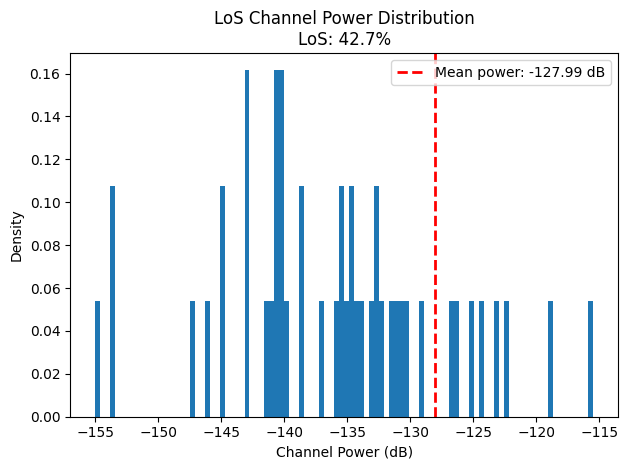

In [13]:
los_sampled_channels = channels[los_indices]
los_channel_power = np.mean(np.abs(los_sampled_channels) ** 2, axis=(1, 2, 3))
los_channel_power_db = 10 * np.log10(los_channel_power)
los_mean_linear_power = los_channel_power.mean()
los_mean_power_db = 10 * np.log10(los_mean_linear_power)

# Percentage of LoS / nLoS samples
los_percentage = meta["los_binary"].sum() / meta["los_binary"].size * 100
nlos_percentage = 100 - los_percentage

plt.hist(los_channel_power_db, bins=100, density=True)
plt.xlabel("Channel Power (dB)")
plt.ylabel("Density")
plt.title(f"LoS Channel Power Distribution\nLoS: {los_percentage:.1f}%")
plt.axvline(
    los_mean_power_db,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean power: {los_mean_power_db:.2f} dB",
)
plt.legend()
plt.tight_layout()
plt.show()


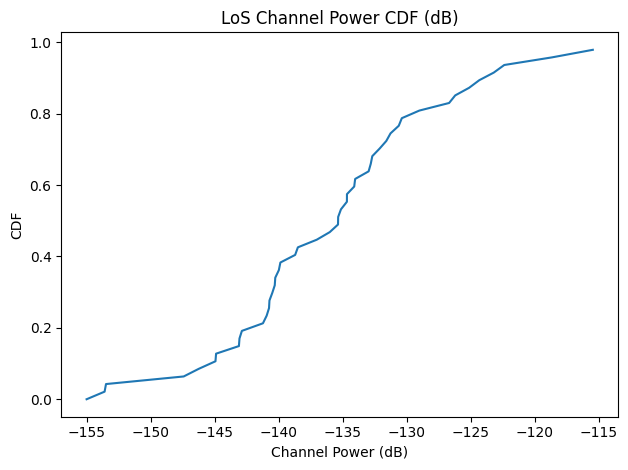

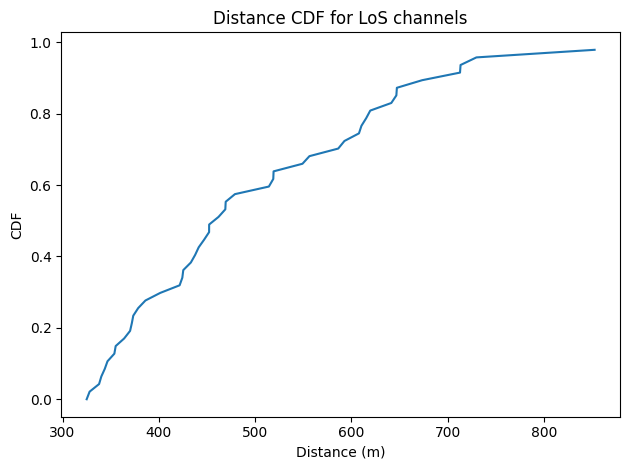

In [15]:
# LoS: CDFs
plt.plot(
    np.sort(los_channel_power_db),
    np.arange(len(los_channel_power_db)) / len(los_channel_power_db),
)
plt.xlabel("Channel Power (dB)")
plt.ylabel("CDF")
plt.title("LoS Channel Power CDF (dB)")
plt.tight_layout()
plt.show()

# LoS: distance CDF (use LoS-only RX positions)
los_rx_positions = rx_positions[los_indices]
los_channel_distances = np.linalg.norm(los_rx_positions - tx_position, axis=(1, 2))
los_distance_cdf_x = np.sort(los_channel_distances)
plt.plot(los_distance_cdf_x, np.arange(len(los_distance_cdf_x)) / len(los_distance_cdf_x))
plt.xlabel("Distance (m)")
plt.ylabel("CDF")
plt.title("Distance CDF for LoS channels")
plt.tight_layout()
plt.show()

Mean linear power of nLoS channels:  3.7425088e-15


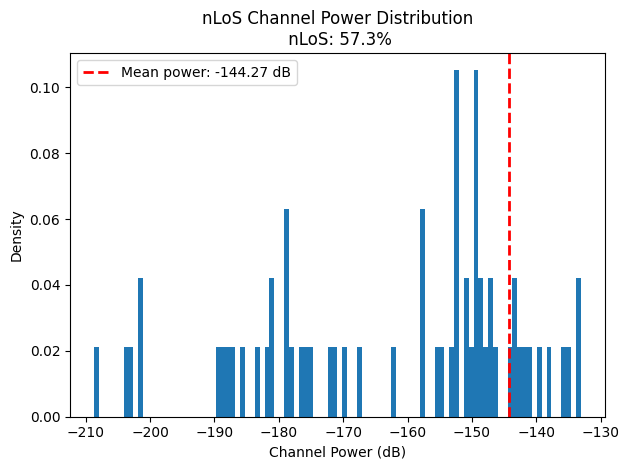

In [18]:
nlos_sampled_channels = channels[nlos_indices]
nlos_channel_power = np.mean(np.abs(nlos_sampled_channels) ** 2, axis=(1, 2, 3))
nlos_channel_power_db = 10 * np.log10(nlos_channel_power)
nlos_mean_linear_power = nlos_channel_power.mean()
nlos_mean_power_db = 10 * np.log10(nlos_mean_linear_power)
print("Mean linear power of nLoS channels: ", nlos_mean_linear_power)

# Percentage of LoS / nLoS samples
los_percentage = meta["los_binary"].sum() / meta["los_binary"].size * 100
nlos_percentage = 100 - los_percentage

# nLoS: histograms
plt.hist(nlos_channel_power_db, bins=100, density=True)
plt.xlabel("Channel Power (dB)")
plt.ylabel("Density")
plt.title(f"nLoS Channel Power Distribution\n nLoS: {nlos_percentage:.1f}%")
plt.axvline(
    nlos_mean_power_db,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean power: {nlos_mean_power_db:.2f} dB",
)
plt.legend()
plt.tight_layout()
plt.show()

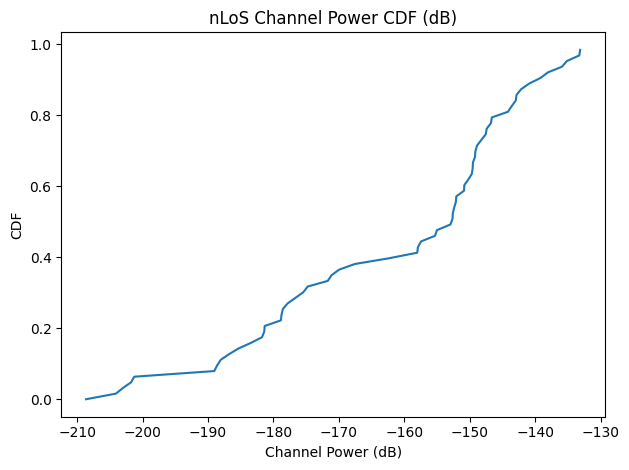

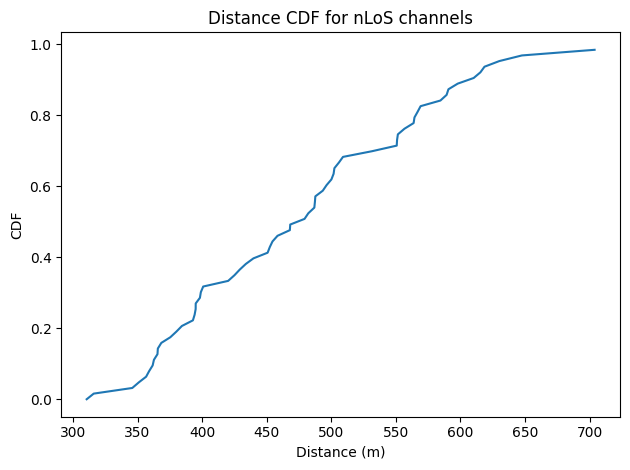

In [19]:
# nLoS: CDFs
plt.plot(
    np.sort(nlos_channel_power_db),
    np.arange(len(nlos_channel_power_db)) / len(nlos_channel_power_db),
)
plt.xlabel("Channel Power (dB)")
plt.ylabel("CDF")
plt.title("nLoS Channel Power CDF (dB)")
plt.tight_layout()
plt.show()

# nLoS: distance CDF (use nLoS-only RX positions)
nlos_rx_positions = rx_positions[nlos_indices]
nlos_channel_distances = np.linalg.norm(nlos_rx_positions - tx_position, axis=(1, 2))
nlos_distance_cdf_x = np.sort(nlos_channel_distances)
plt.plot(nlos_distance_cdf_x, np.arange(len(nlos_distance_cdf_x)) / len(nlos_distance_cdf_x))
plt.xlabel("Distance (m)")
plt.ylabel("CDF")
plt.title("Distance CDF for nLoS channels")
plt.tight_layout()
plt.show()